In this notebook I will select the amines that I will use for the next 2 ones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import seaborn as sns

from scripts.smarts_patterns import (
    SMARTS_PRIMARY_AMINE,
    SMARTS_SECONDARY_AMINE,
    SMARTS_TERTIARY_AMINE,
)
from scripts.chembl_utils import fetch_chembl_molecules, extract_smiles_and_ids
from scripts.cheminformatics_utils import (
    calculate_tanimoto_similarity,
    process_molecule,
    calc_descriptors,
)

In [2]:
DESIRED_TOTAL_MOLECULES = 300

# Get amines

 - *** get 10'000 random molecules from Chembl
 - *** if one unique aliphatic amine is present, flag each of them as "primary, secondary or tertiary"
 - when I have enough amines (at least 1'000), analyze them:
   - *** distribution of molecular properties
   - *** diversity
 - generate conformers with rdkit

 - get a list of molecules from Chembl and store them into a dataframe (~30 seconds for 10k molecules)

In [3]:
# get the molecules from chembl (~30 sec for 10k molecules)
all_molecules = fetch_chembl_molecules(DESIRED_TOTAL_MOLECULES * 10)
df_all_mols = extract_smiles_and_ids(all_molecules)

 - process amines

In [4]:
patterns = {
    "primary": Chem.MolFromSmarts(SMARTS_PRIMARY_AMINE),
    "secondary": Chem.MolFromSmarts(SMARTS_SECONDARY_AMINE),
    "tertiary": Chem.MolFromSmarts(SMARTS_TERTIARY_AMINE),
}

In [5]:
df_all_mols[["has_single_amine", "amine_type"]] = (
    df_all_mols["smiles"]
    .apply(lambda smi: process_molecule(Chem.MolFromSmiles(smi), patterns))
    .apply(pd.Series)
)
df_all_mols

,smiles,chembl_id,has_single_amine,amine_type
0,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,CHEMBL6329,False,NaN
1,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,CHEMBL6328,False,NaN
2,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,CHEMBL265667,False,NaN
3,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,CHEMBL6362,False,NaN
4,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,CHEMBL267864,False,NaN
...,...,...,...,...
2963,S=C(Nc1ccc(Cl)cc1)OC(Cn1ccnc1)c1ccc(Cl)cc1Cl,CHEMBL8376,True,secondary
2964,CC(=O)OCC1=C(C(=O)[O-])N2C(=O)/C(=C/c3ccccc3)[...,CHEMBL268631,True,tertiary
2965,CN(C)CCCCCNc1ccc2ncn3c4ccc(O)cc4c(=O)c1c23,CHEMBL268947,False,NaN
2966,CCCCN(CCCC)CCNc1ccc2ncn3c4ccc(O)cc4c(=O)c1c23,CHEMBL8528,False,NaN


 - verify how many molecules have one single amine, and what type of amine this is

In [6]:
print(
    f"The amines are {df_all_mols.has_single_amine.sum()} "
    f"out of {len(df_all_mols)}, i.e. {df_all_mols.has_single_amine.mean()*100:.2f}%"
)

The amines are 954 out of 2968, i.e. 32.14%


In [7]:
df_amines = df_all_mols[df_all_mols.has_single_amine]
df_amines = df_amines.sample(n=DESIRED_TOTAL_MOLECULES, random_state=1).reset_index(
    drop=True
)

Text(0.5, 1.0, 'Distribution of amine types')

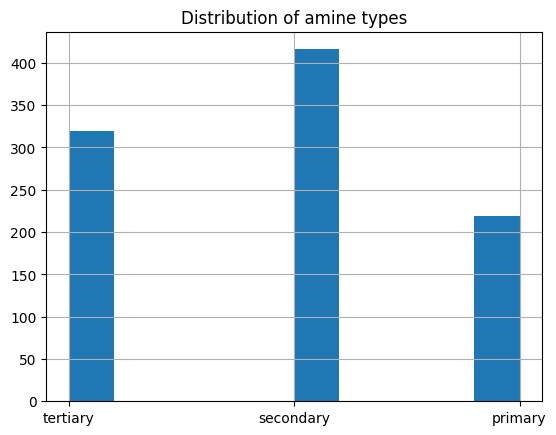

In [8]:
ax = df_all_mols.amine_type.hist()
ax.set_title("Distribution of amine types")  # type: ignore

In [9]:
df_amines

,smiles,chembl_id,has_single_amine,amine_type
0,C[C@@H](N)Cc1c2ccoc2c(Br)c2ccoc12.Cl,CHEMBL6706,True,primary
1,C[C@@H]1O[C@H](n2cnc(C(N)=O)n2)[C@@H](O)[C@H]1O,CHEMBL274535,True,primary
2,CC[C@H]1Cc2cc3c(C(F)(F)F)cc(O)nc3cc2N[C@@H]1CC,CHEMBL6959,True,secondary
3,CC(C)Nc1nc2ccccc2n2cnnc12,CHEMBL269318,True,secondary
4,CCOC(=O)C1=C(O)C(=O)N(c2cccc3ccccc23)C1,CHEMBL7013,True,tertiary
...,...,...,...,...
295,CN(N=O)c1cc(O)ccc1O,CHEMBL269733,True,tertiary
296,O=C(N[C@@H](Cc1cccs1)C(=O)O)c1ccccc1Br,CHEMBL7742,True,secondary
297,Nc1ncnc2c1ncn2Cc1ccccc1,CHEMBL266094,True,primary
298,CN1CCC[C@H]1c1cccnc1,CHEMBL3,True,tertiary


# Analyze the pool of amines

 - distribution of molecular descriptors

In [10]:
descriptors = calc_descriptors(df_amines.smiles)  # type: ignore
df_amines = df_amines.assign(**descriptors)

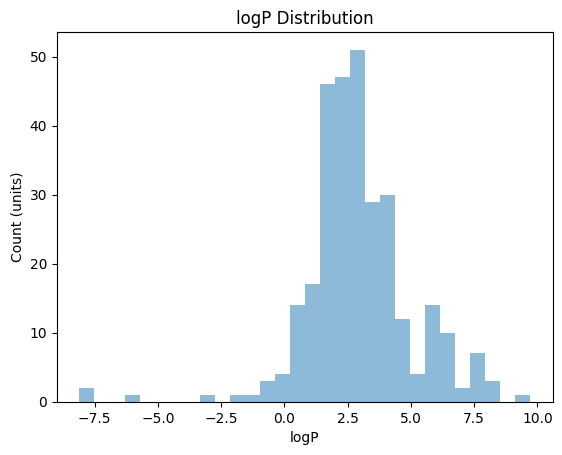

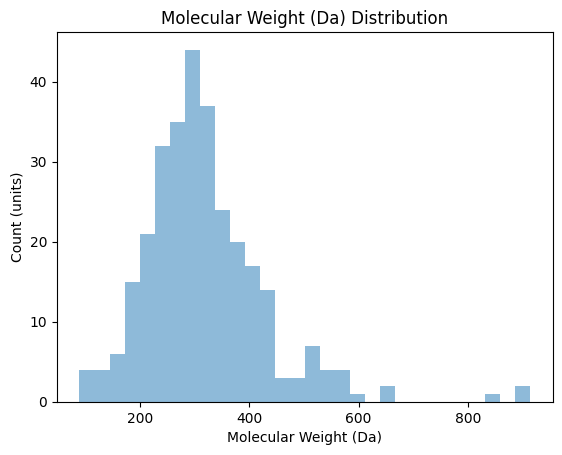

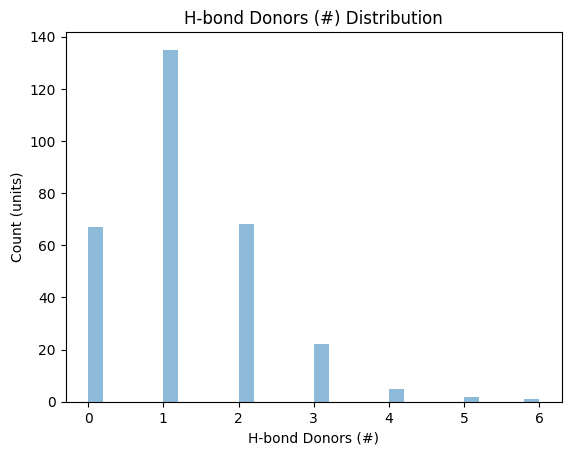

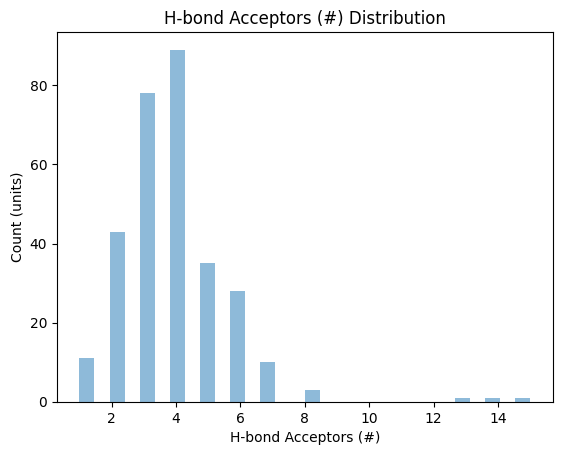

In [11]:
for desc, label in zip(
    ["logP", "MW", "HDonors", "HAcceptors"],
    ["logP", "Molecular Weight (Da)", "H-bond Donors (#)", "H-bond Acceptors (#)"],
):
    plt.figure()
    plt.hist(df_amines[desc], bins=30, alpha=0.5)
    plt.xlabel(label)
    plt.ylabel("Count (units)")
    plt.title(f"{label} Distribution")
    plt.show()

 - diversity

In [12]:
mfp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
mols = [Chem.MolFromSmiles(smiles) for smiles in df_amines.smiles]
fps = [mfp.GetFingerprint(m) for m in mols]

In [13]:
# Calculate all-vs-all Tanimoto similarity
similarity_matrix = calculate_tanimoto_similarity(fps)
# Quantitative check: Average similarity (lower = more diverse)
print(
    f"Mean Tanimoto: {np.mean(similarity_matrix[np.triu_indices(len(fps), k=1)]):.2f}"
    f" and standard deviation {np.std(similarity_matrix[np.triu_indices(len(fps), k=1)]):.2f}"
)

Mean Tanimoto: 0.12 and standard deviation 0.07


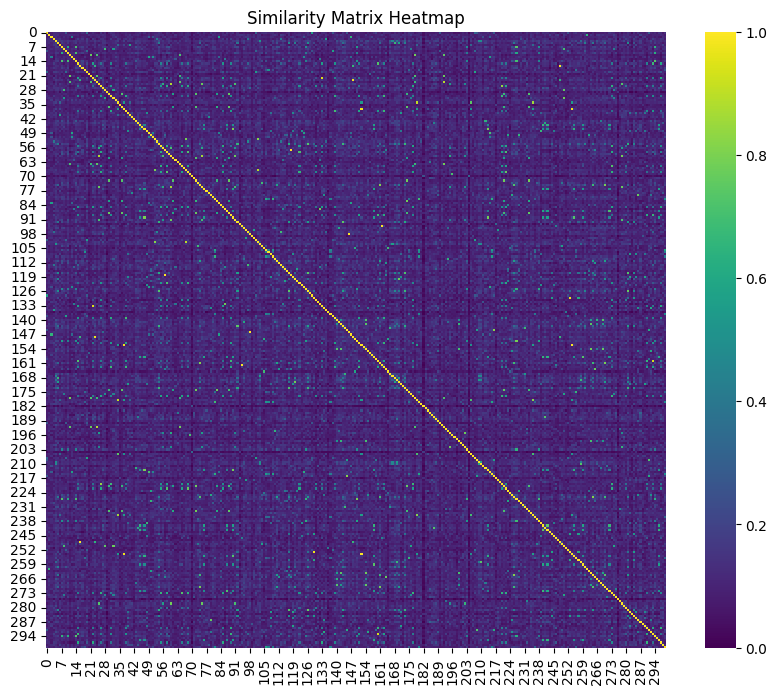

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='viridis', annot=False)
plt.title('Similarity Matrix Heatmap')
plt.show()

### Save dataframe of amines

In [15]:
df_amines.to_csv(
    "/Users/aprunotto/Documents/alessio-code/sterics-github/sterics-descriptors/data/selected_amines.csv",
    index=False,
)